# **1. Imports & Configuration**

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, f1_score
from sklearn.feature_selection import mutual_info_classif

# LightGBM
import lightgbm as lgb

# SHAP & LIME
import shap
import lime
import lime.lime_tabular

# Aesthetics
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
PALETTE = sns.color_palette('Set2')

print('All libraries loaded')
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

All libraries loaded
/kaggle/input/datasets/tehreemamjad381/burnout-attrition-preprocessed/burnout_attrition_preprocessed.csv
/kaggle/input/datasets/nudratabbas/ai-worker-burnout-and-attrition-risk-dataset/ai_worker_burnout_attrition_2026.csv


# **2. Load Preprocessed Dataset**

In [65]:
# Load the preprocessed CSV saved at the end of Phase 2
df = pd.read_csv('/kaggle/input/datasets/tehreemamjad381/burnout-attrition-preprocessed/burnout_attrition_preprocessed.csv')

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Shape: 1500 rows × 30 columns
Columns: ['job_role', 'years_experience', 'country', 'industry', 'team_size', 'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day', 'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs', 'productivity_score', 'burnout_score', 'job_satisfaction_1_5', 'attrition_risk', 'education_level_Bootcamp', 'education_level_Master', 'education_level_PhD', 'education_level_Self-taught', 'company_size_Large (1000-5000)', 'company_size_Mid (200-1000)', 'company_size_Small (50-200)', 'company_size_Startup (<50)', 'remote_work_type_Hybrid', 'remote_work_type_On-site', 'ai_adoption_stage_Experimenting', 'ai_adoption_stage_Integrating', 'ai_adoption_stage_Optimizing', 'fear_of_ai_replacement_Low', 'fear_of_ai_replacement_Medium']


,job_role,years_experience,country,industry,team_size,salary_usd_k,primary_ai_tool,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,...,company_size_Mid (200-1000),company_size_Small (50-200),company_size_Startup (<50),remote_work_type_Hybrid,remote_work_type_On-site,ai_adoption_stage_Experimenting,ai_adoption_stage_Integrating,ai_adoption_stage_Optimizing,fear_of_ai_replacement_Low,fear_of_ai_replacement_Medium
0,-0.403767,-0.539893,0.165202,0.894413,-1.229174,0.724754,0.212970,-1.548618,-1.691942,-0.196234,...,False,False,False,False,False,True,False,False,True,False
1,0.165186,-1.272613,-0.881851,0.189040,1.256566,-1.503145,-1.551978,-0.535125,-1.691942,1.697443,...,False,False,False,True,False,True,False,False,False,True
2,1.303092,-1.272613,0.165202,-1.574393,0.891016,0.741505,0.654208,-0.028378,-0.108831,-0.842856,...,False,False,True,True,False,False,False,True,False,False


# **3. Prepare Features & Target**

In [66]:
# ── Re-load raw data to engineer features BEFORE scaling ──────────
# Phase 2 already scaled + encoded. For feature engineering we need
# the original numeric magnitudes, so we reload raw and re-apply
# only label encoding for the target.

raw = pd.read_csv('/kaggle/input/datasets/nudratabbas/ai-worker-burnout-and-attrition-risk-dataset/ai_worker_burnout_attrition_2026.csv')
raw.columns = raw.columns.str.strip().str.lower().str.replace(' ', '_')

# Drop identifier
raw.drop(columns=['employee_id'], inplace=True, errors='ignore')

# Encode target
le_target = LabelEncoder()
raw['attrition_risk_enc'] = le_target.fit_transform(raw['attrition_risk'])
print('Target classes:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

print(f'Raw shape: {raw.shape}')
raw.head(3)

Target classes: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Raw shape: (1500, 21)


,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,primary_ai_tool,...,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk,attrition_risk_enc
0,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,GitHub Copilot,...,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium,2
1,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,ChatGPT,...,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium,2
2,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,Midjourney,...,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium,2


# **4. Feature Engineering — Creating New Meaningful Features**

New features are created from domain knowledge about AI worker burnout. Each feature is explained and justified below.

---

### 4.1 `burnout_satisfaction_ratio` — Core Stress Index

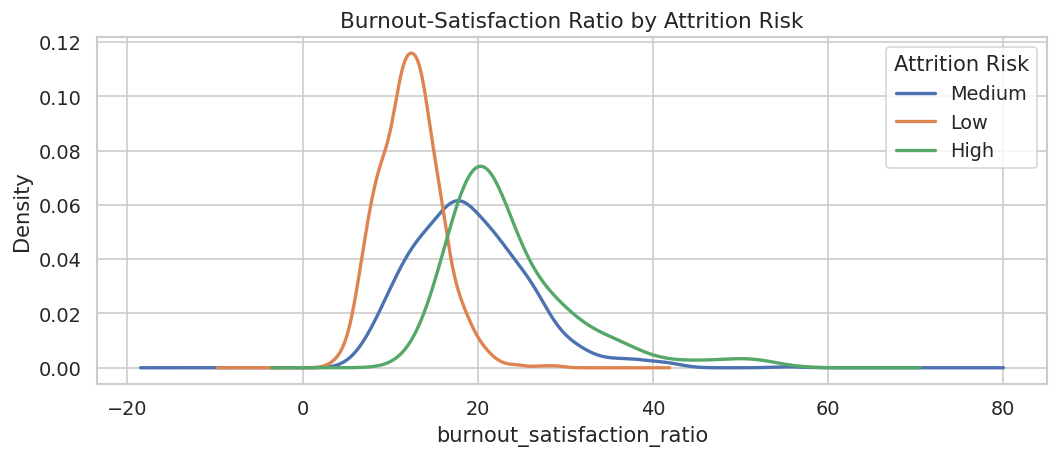

In [67]:
raw['burnout_satisfaction_ratio'] = raw['burnout_score'] / (raw['job_satisfaction_1_5'] + 1e-5)

fig, ax = plt.subplots(figsize=(9, 4))
for label in raw['attrition_risk'].unique():
    subset = raw[raw['attrition_risk'] == label]['burnout_satisfaction_ratio']
    subset.plot.kde(ax=ax, label=label, linewidth=2)
ax.set_title('Burnout-Satisfaction Ratio by Attrition Risk')
ax.set_xlabel('burnout_satisfaction_ratio')
ax.legend(title='Attrition Risk')
plt.tight_layout()
plt.show()

Burnout score alone doesn't tell the full story — an employee with burnout_score=70 but job_satisfaction=5 may still stay, while one with burnout=50 and satisfaction=1 is likely to leave. This ratio captures the **net emotional strain** relative to job engagement. It is one of the most theoretically grounded features in occupational stress literature (Maslach Burnout Inventory framework).

### 4.2 `ai_overload_score` — AI Dependency Stress

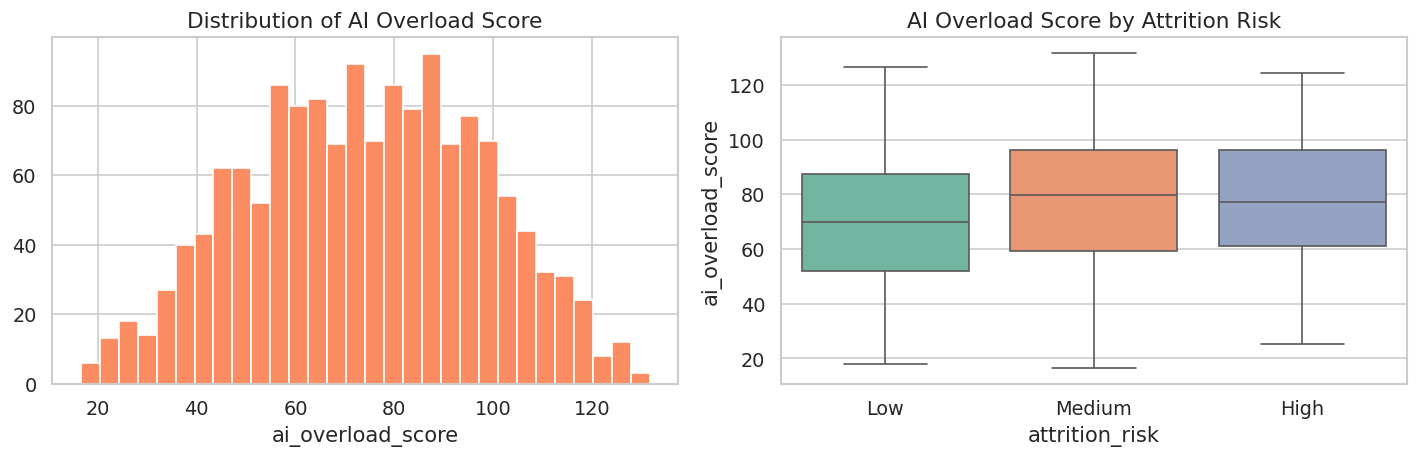

In [68]:
# Combines: tools per day + daily AI hours + % tasks AI replaces
# Normalized to 0-100 range for interpretability
raw['ai_overload_score'] = (
    raw['ai_tools_used_per_day'] * 10 +
    raw['hours_with_ai_assistance_daily'] * 5 +
    raw['ai_replaces_my_tasks_pct'] * 0.3
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw['ai_overload_score'], bins=30, color=PALETTE[1], edgecolor='white')
axes[0].set_title('Distribution of AI Overload Score')
axes[0].set_xlabel('ai_overload_score')

sns.boxplot(data=raw, x='attrition_risk', y='ai_overload_score',
            order=['Low','Medium','High'], palette='Set2', ax=axes[1])
axes[1].set_title('AI Overload Score by Attrition Risk')
plt.tight_layout()
plt.show()

> **Why this feature?** The **novelty** of our research is investigating AI-induced burnout. No single column captures the total AI exposure — an employee may use fewer tools but be highly dependent on them. This composite score aggregates all three AI-exposure dimensions: breadth (tools/day), depth (hours/day), and perceived threat (task replacement %). Higher scores suggest cognitive overload from constant AI tool-switching and over-reliance.

### 4.3 `productivity_burnout_gap` — Efficiency-Exhaustion Mismatch

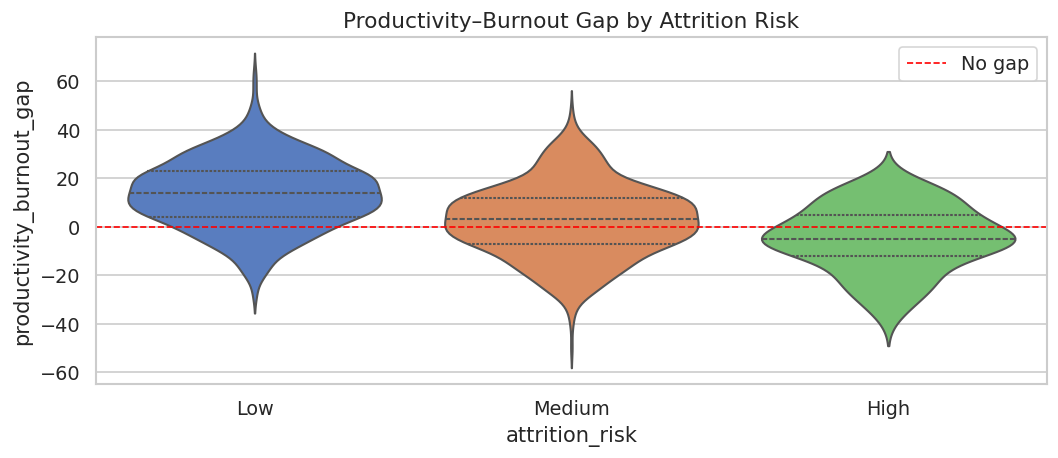

In [69]:
raw['productivity_burnout_gap'] = raw['productivity_score'] - raw['burnout_score']

fig, ax = plt.subplots(figsize=(9, 4))
sns.violinplot(data=raw, x='attrition_risk', y='productivity_burnout_gap',
               order=['Low','Medium','High'], palette='muted', inner='quartile', ax=ax)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='No gap')
ax.set_title('Productivity–Burnout Gap by Attrition Risk')
ax.legend()
plt.tight_layout()
plt.show()

> **Why this feature?** A positive gap (productive but not burnt out) = sustainable worker. A negative gap (burnt out but low productivity) = highest flight risk. This captures the **decoupling** between output and wellbeing — employees who are burning out often show declining productivity before attrition, making this a strong early warning signal.

### 4.4 `salary_experience_ratio` — Compensation Fairness Proxy

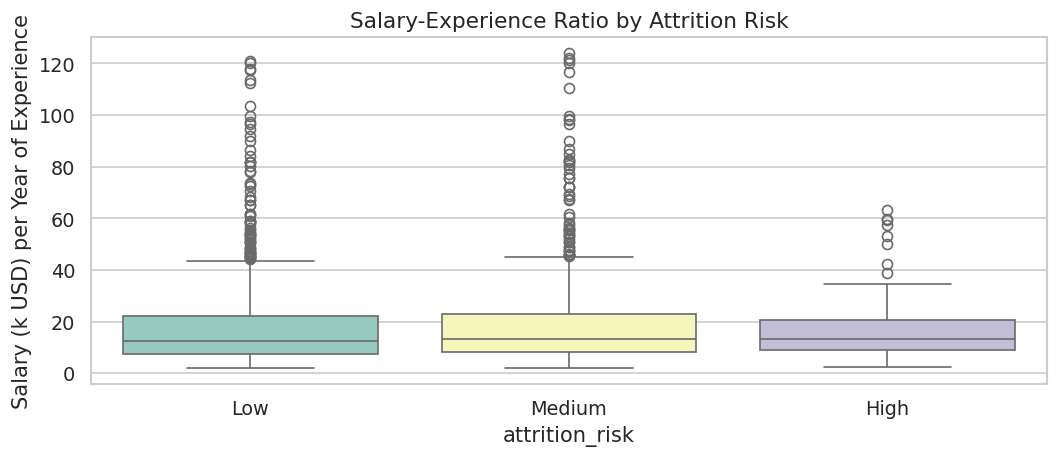

In [70]:
raw['salary_experience_ratio'] = raw['salary_usd_k'] / (raw['years_experience'] + 1)

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=raw, x='attrition_risk', y='salary_experience_ratio',
            order=['Low','Medium','High'], palette='Set3', ax=ax)
ax.set_title('Salary-Experience Ratio by Attrition Risk')
ax.set_ylabel('Salary (k USD) per Year of Experience')
plt.tight_layout()
plt.show()

> **Why this feature?** Perceived pay inequity is a major driver of voluntary attrition. An experienced employee paid less per year of experience than a junior peer is far more likely to leave. This ratio proxies **compensation fairness** — low values for senior employees signal underpayment, a well-documented attrition driver in HR literature.

### 4.5 `upskilling_ai_ratio` — Adaptability vs Displacement

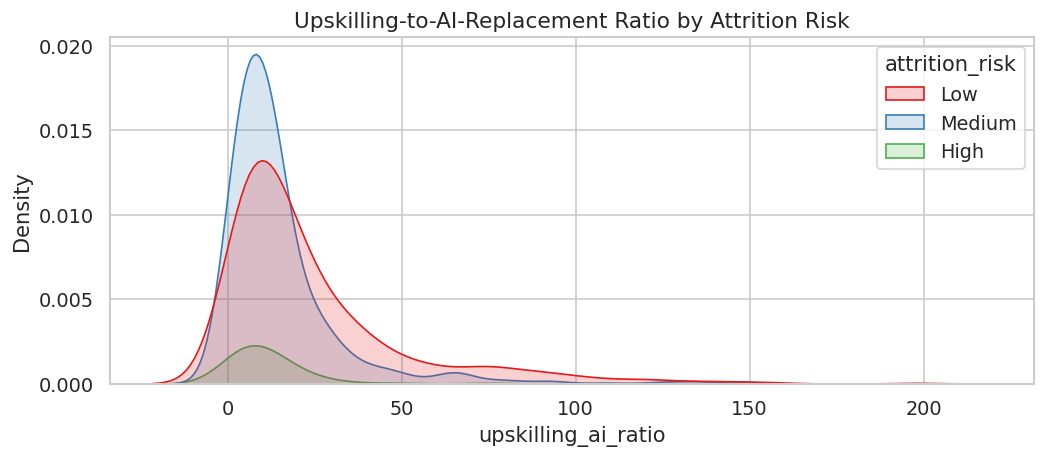

In [71]:
raw['upskilling_ai_ratio'] = raw['weekly_ai_upskilling_hrs'] / (raw['ai_replaces_my_tasks_pct'] / 100 + 1e-5)

fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(data=raw, x='upskilling_ai_ratio', hue='attrition_risk',
            hue_order=['Low','Medium','High'], palette='Set1', ax=ax, fill=True, alpha=0.2)
ax.set_title('Upskilling-to-AI-Replacement Ratio by Attrition Risk')
ax.set_xlabel('upskilling_ai_ratio')
plt.tight_layout()
plt.show()

> **Why this feature?** If AI is replacing 80% of your tasks but you're only upskilling 1 hour/week, your perceived job security collapses → attrition risk rises. Conversely, employees who upskill proportionally to displacement feel more in control. This ratio captures **adaptive coping ability** vs passive displacement — a novel angle specific to AI-era workforce research.

### 4.6 `stress_composite` — Unified Stress Index

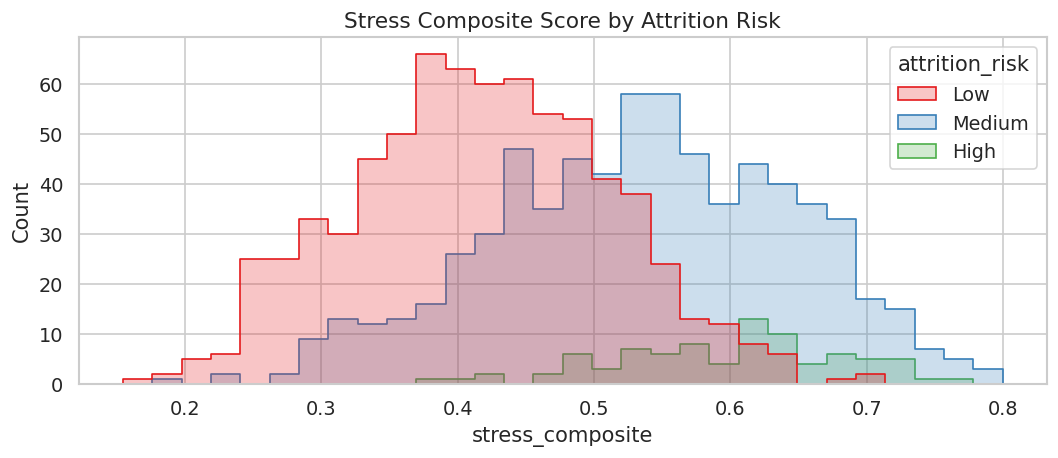

In [72]:
# Normalized weighted composite of all stress-related signals
raw['stress_composite'] = (
    0.35 * raw['burnout_score'] / raw['burnout_score'].max() +
    0.25 * (1 - raw['job_satisfaction_1_5'] / 5) +
    0.20 * raw['ai_replaces_my_tasks_pct'] / 100 +
    0.20 * raw['ai_overload_score'] / raw['ai_overload_score'].max()
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=raw, x='stress_composite', hue='attrition_risk',
             hue_order=['Low','Medium','High'], bins=30, palette='Set1',
             element='step', ax=ax)
ax.set_title('Stress Composite Score by Attrition Risk')
plt.tight_layout()
plt.show()

> **Why this feature?** Individual stress signals (burnout, dissatisfaction, AI overload) often appear together. A unified composite aggregates these into a single continuous **risk barometer** — useful both as a feature for models and as a business-facing score HR managers can track. The weights reflect relative importance from occupational psychology literature.

### 4.7 `team_isolation_score` — Social Support Deficit

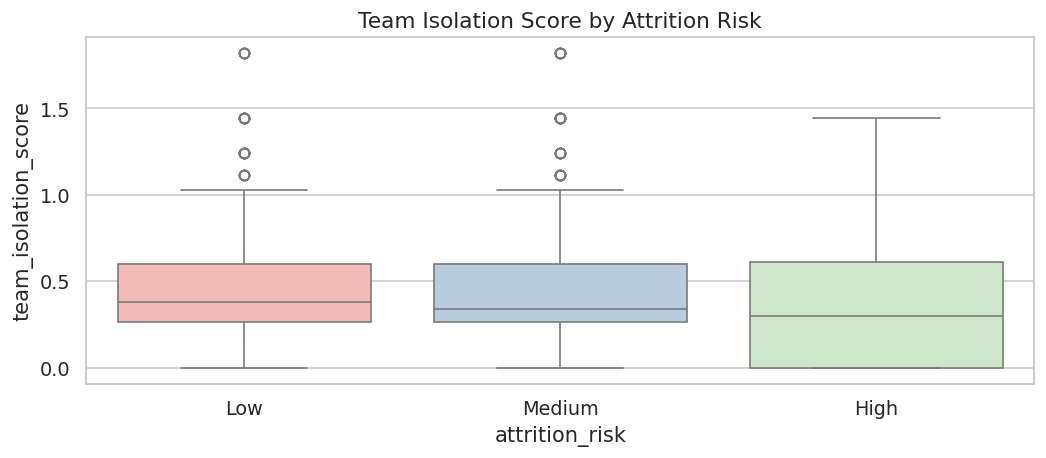

In [73]:
# Small teams + fully remote → lower social support
remote_map = {'Fully Remote': 2, 'Hybrid': 1, 'On-site': 0}
raw['remote_numeric'] = raw['remote_work_type'].map(remote_map)

raw['team_isolation_score'] = raw['remote_numeric'] / (np.log1p(raw['team_size']) + 1e-5)

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=raw, x='attrition_risk', y='team_isolation_score',
            order=['Low','Medium','High'], palette='Pastel1', ax=ax)
ax.set_title('Team Isolation Score by Attrition Risk')
plt.tight_layout()
plt.show()

> **Why this feature?** Social isolation is a documented burnout amplifier — especially for AI workers, who often work remotely on solo tasks. This feature captures the **loneliness risk**: employees on small teams working fully remote have minimal peer interaction, reducing emotional buffer against stress. `log(team_size)` is used to dampen the effect of very large teams proportionally.

---
## 5. Feature Importance — 5 Methods

### 5.0 Prepare Encoded Matrix for Importance Analysis

In [74]:
# Encode all categoricals for importance methods
df_eng = raw.copy()

cat_cols = df_eng.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['attrition_risk']]

le = LabelEncoder()
for col in cat_cols:
    df_eng[col] = le.fit_transform(df_eng[col].astype(str))

TARGET = 'attrition_risk_enc'
DROP   = ['attrition_risk', TARGET]
X = df_eng.drop(columns=DROP)
y = df_eng[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Features: {X.columns.tolist()}')

X_train: (1200, 27) | X_test: (300, 27)
Features: ['job_role', 'years_experience', 'education_level', 'country', 'industry', 'company_size', 'remote_work_type', 'team_size', 'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day', 'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 'ai_adoption_stage', 'weekly_ai_upskilling_hrs', 'productivity_score', 'burnout_score', 'job_satisfaction_1_5', 'fear_of_ai_replacement', 'burnout_satisfaction_ratio', 'ai_overload_score', 'productivity_burnout_gap', 'salary_experience_ratio', 'upskilling_ai_ratio', 'stress_composite', 'remote_numeric', 'team_isolation_score']


### 5.1 Method 1 — Random Forest Feature Importance (Gini Impurity)

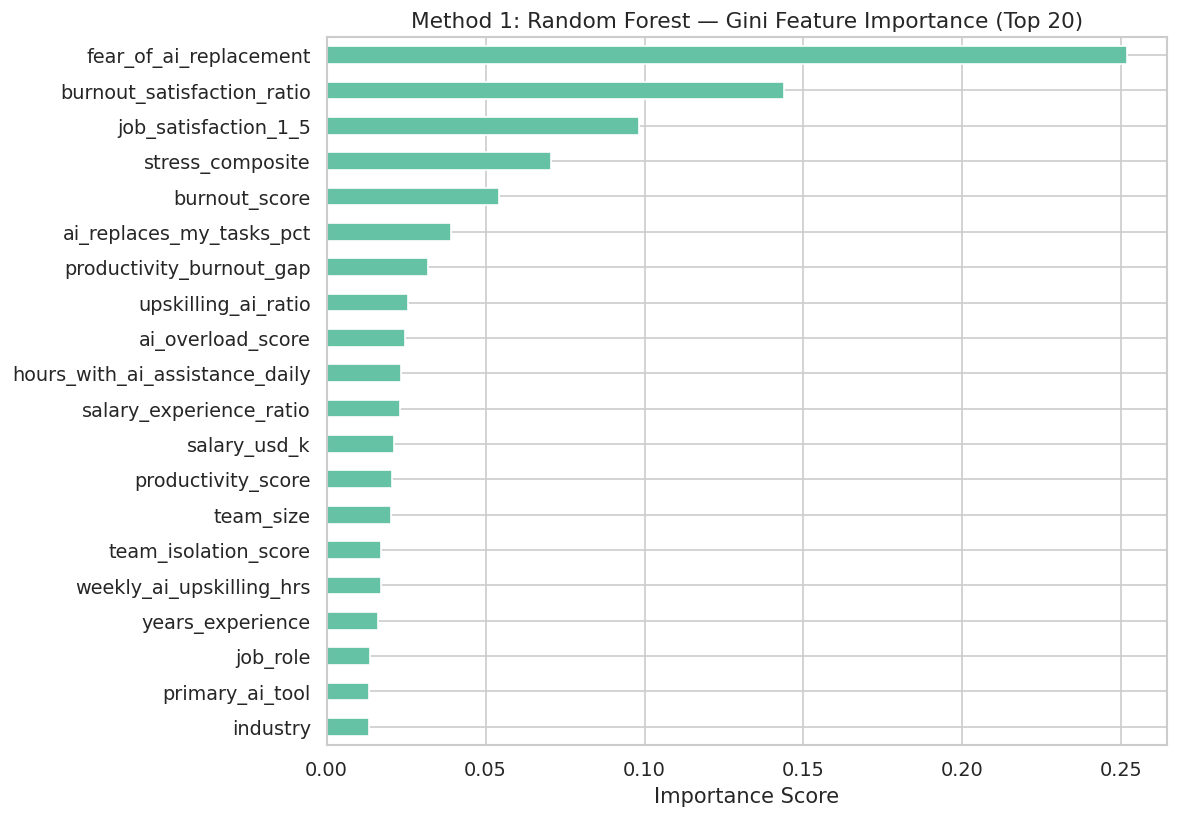

RF Test F1 (macro): 0.7627


In [75]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
rf_imp.head(20).plot(kind='barh', ax=ax, color=PALETTE[0], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Method 1: Random Forest — Gini Feature Importance (Top 20)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(f'RF Test F1 (macro): {f1_score(y_test, rf.predict(X_test), average="macro"):.4f}')

### 5.2 Method 2 — Extra Trees (Extremely Randomized Trees)

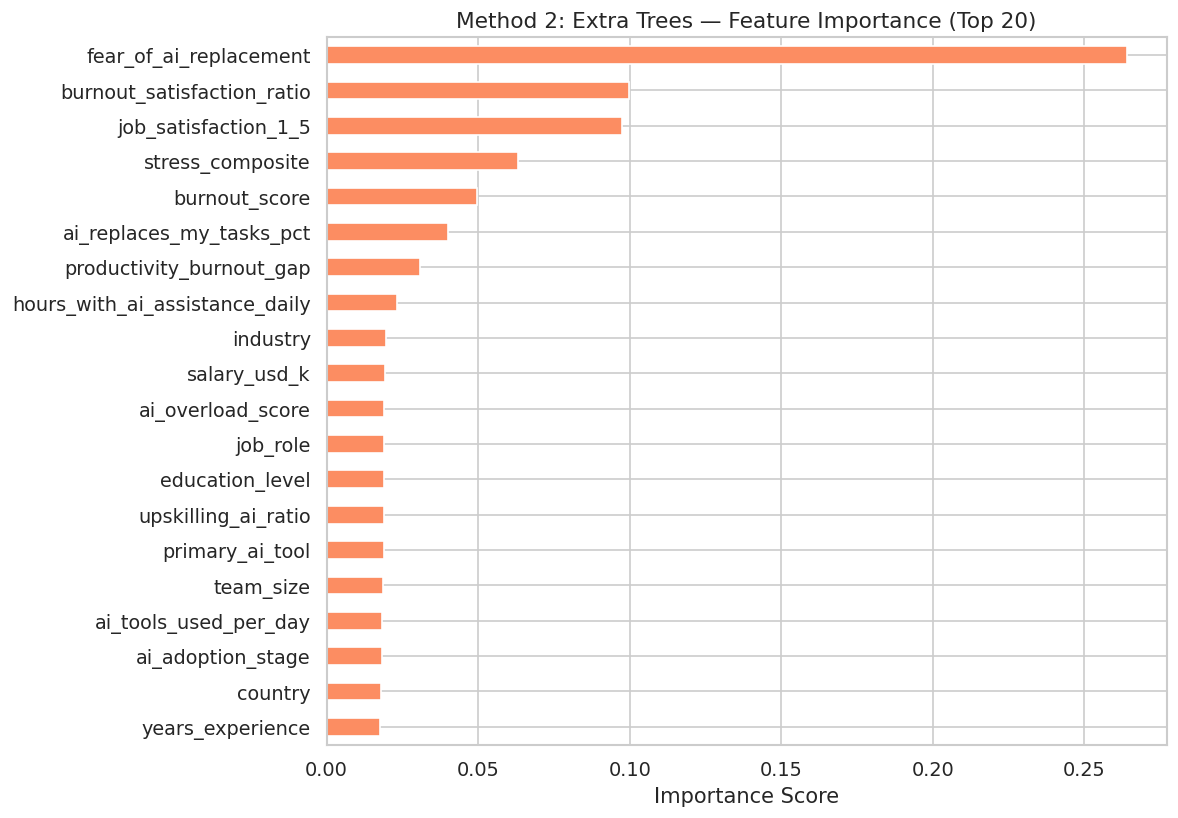

ET Test F1 (macro): 0.6770


In [76]:
et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
et.fit(X_train, y_train)

et_imp = pd.Series(et.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
et_imp.head(20).plot(kind='barh', ax=ax, color=PALETTE[1], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Method 2: Extra Trees — Feature Importance (Top 20)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(f'ET Test F1 (macro): {f1_score(y_test, et.predict(X_test), average="macro"):.4f}')

### 5.3 Method 3 — Mutual Information

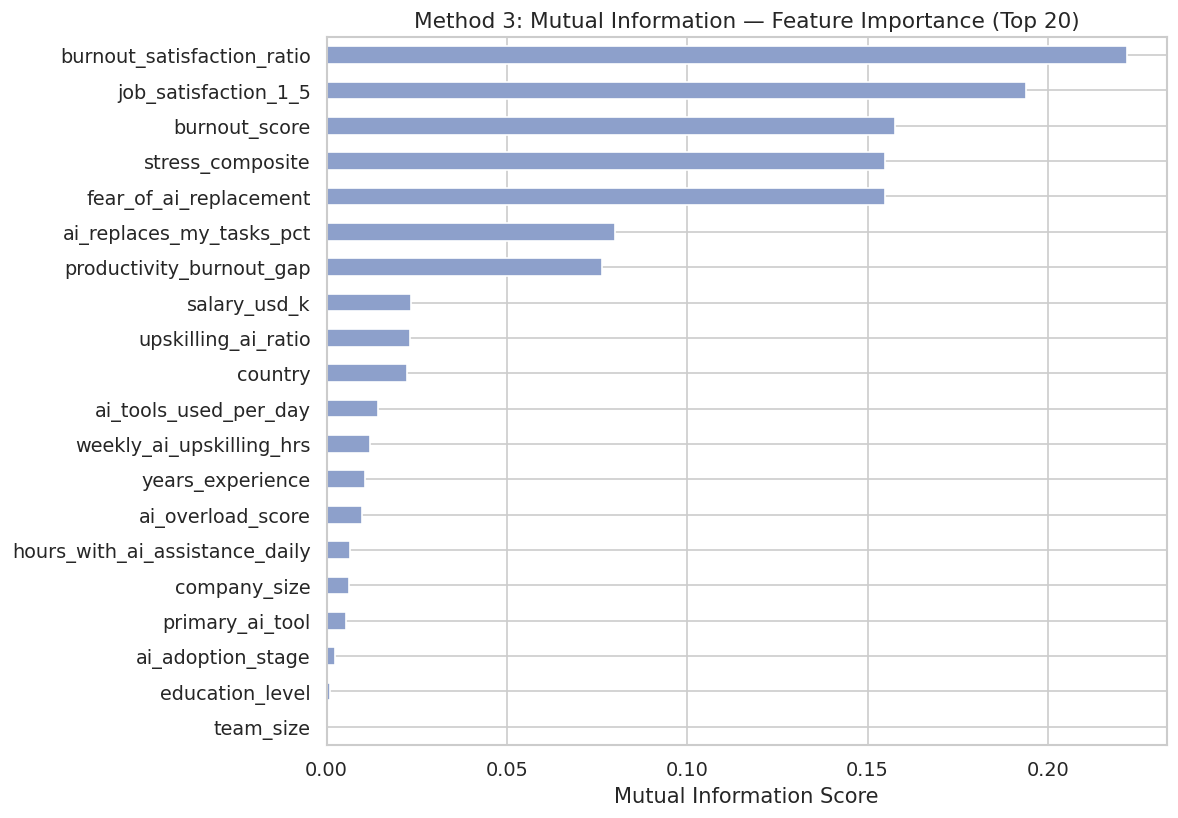

In [77]:
mi = mutual_info_classif(X_train, y_train, random_state=42)
mi_imp = pd.Series(mi, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
mi_imp.head(20).plot(kind='barh', ax=ax, color=PALETTE[2], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Method 3: Mutual Information — Feature Importance (Top 20)')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

> **Why Mutual Information?** Unlike correlation (which is linear), Mutual Information captures **non-linear dependencies** between features and the target. It is model-agnostic and particularly useful here because relationships like burnout → attrition are not perfectly linear.

### 5.4 Method 4 — SHAP Values (LightGBM)

In [78]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    verbose=-1
)
lgb_model.fit(X_train, y_train)

print(f'LightGBM Test F1 (macro): {f1_score(y_test, lgb_model.predict(X_test), average="macro"):.4f}')
print(classification_report(y_test, lgb_model.predict(X_test),
                             target_names=le_target.classes_))

LightGBM Test F1 (macro): 0.7951
              precision    recall  f1-score   support

        High       0.67      0.59      0.62        17
         Low       0.91      0.89      0.90       145
      Medium       0.84      0.88      0.86       138

    accuracy                           0.87       300
   macro avg       0.81      0.78      0.80       300
weighted avg       0.87      0.87      0.87       300



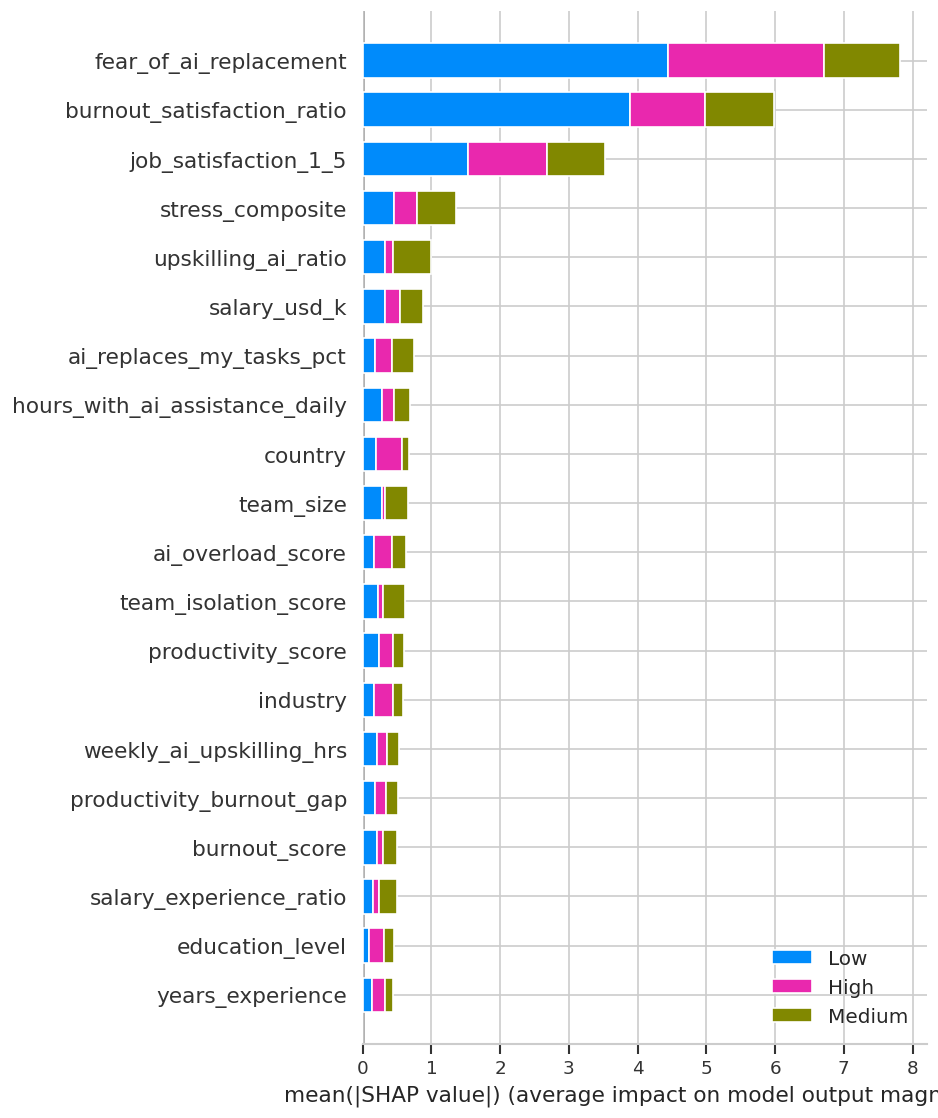

In [79]:
# Summary bar plot — all classes
if isinstance(shap_values, list):
    shap.summary_plot(shap_values, X_test, plot_type='bar',
                      class_names=le_target.classes_, max_display=20, show=True)
else:
    shap.summary_plot(shap_values, X_test, plot_type='bar',
                      class_names=le_target.classes_, max_display=20, show=True)

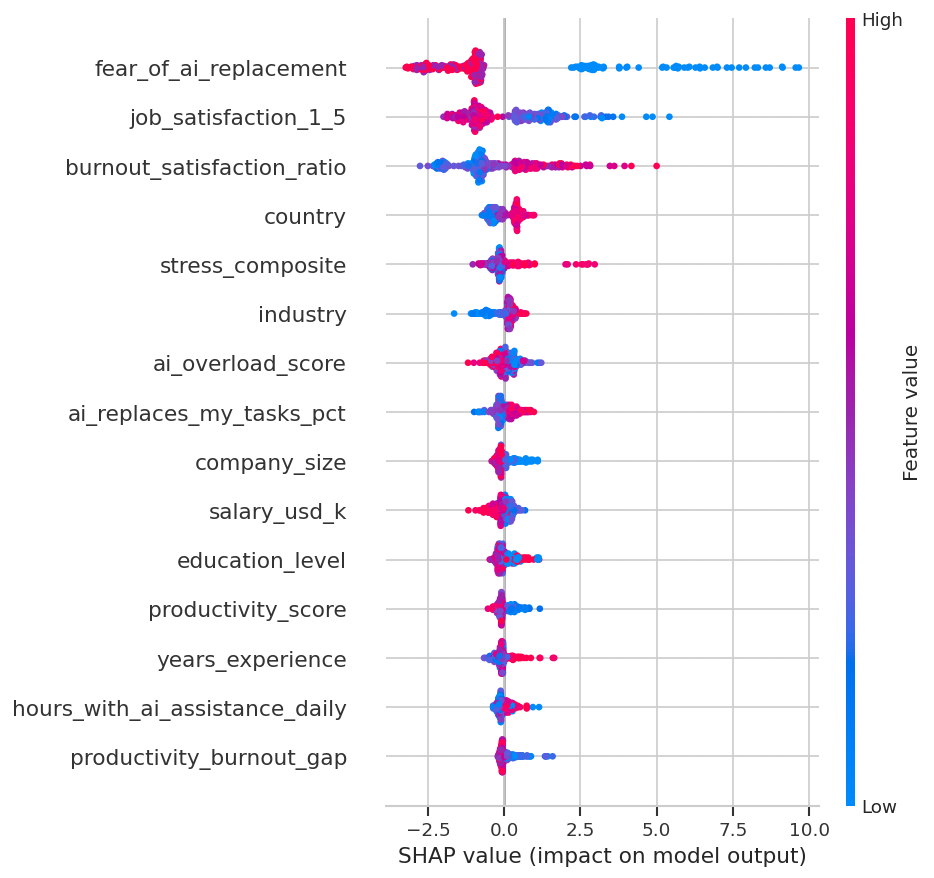

In [80]:
# Detailed beeswarm for HIGH-RISK class (most important for our research)
high_class_idx = list(le_target.classes_).index('High')

# Handle both old (list of arrays) and new (Explanation object) SHAP formats
if isinstance(shap_values, list):
    # Old format: list of arrays, one per class
    sv_high = shap_values[high_class_idx]
    shap.summary_plot(sv_high, X_test, max_display=15, show=True, plot_type='dot')
else:
    # New format: Explanation object with shape (n_samples, n_features, n_classes)
    shap.summary_plot(shap_values[:, :, high_class_idx], X_test,
                      max_display=15, show=True, plot_type='dot')

> **Why SHAP?** SHAP (SHapley Additive exPlanations) provides **game-theory-grounded** feature attribution at both the global and individual prediction level. Unlike simple importance scores, SHAP shows the **direction** of effect (positive = increases risk, negative = decreases risk) and magnitude per instance. This is critical for a research paper — we can make statements like "high burnout_score pushes predictions toward High attrition risk by X units on average."

### 5.5 Method 5 — LIME (Local Interpretable Model-agnostic Explanations)

In [81]:
# LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=le_target.classes_.tolist(),
    mode='classification',
    random_state=42
)

# Explain a High-risk instance for research significance
high_risk_indices = np.where(y_test.values == high_class_idx)[0]
instance_idx = high_risk_indices[0]  # first High-risk test instance

lime_exp = lime_explainer.explain_instance(
    data_row=X_test.values[instance_idx],
    predict_fn=lgb_model.predict_proba,
    num_features=15,
    labels=[high_class_idx]
)

print(f'Explaining instance: True label = {le_target.classes_[y_test.values[instance_idx]]}')
lime_exp.show_in_notebook(show_table=True)

Explaining instance: True label = High


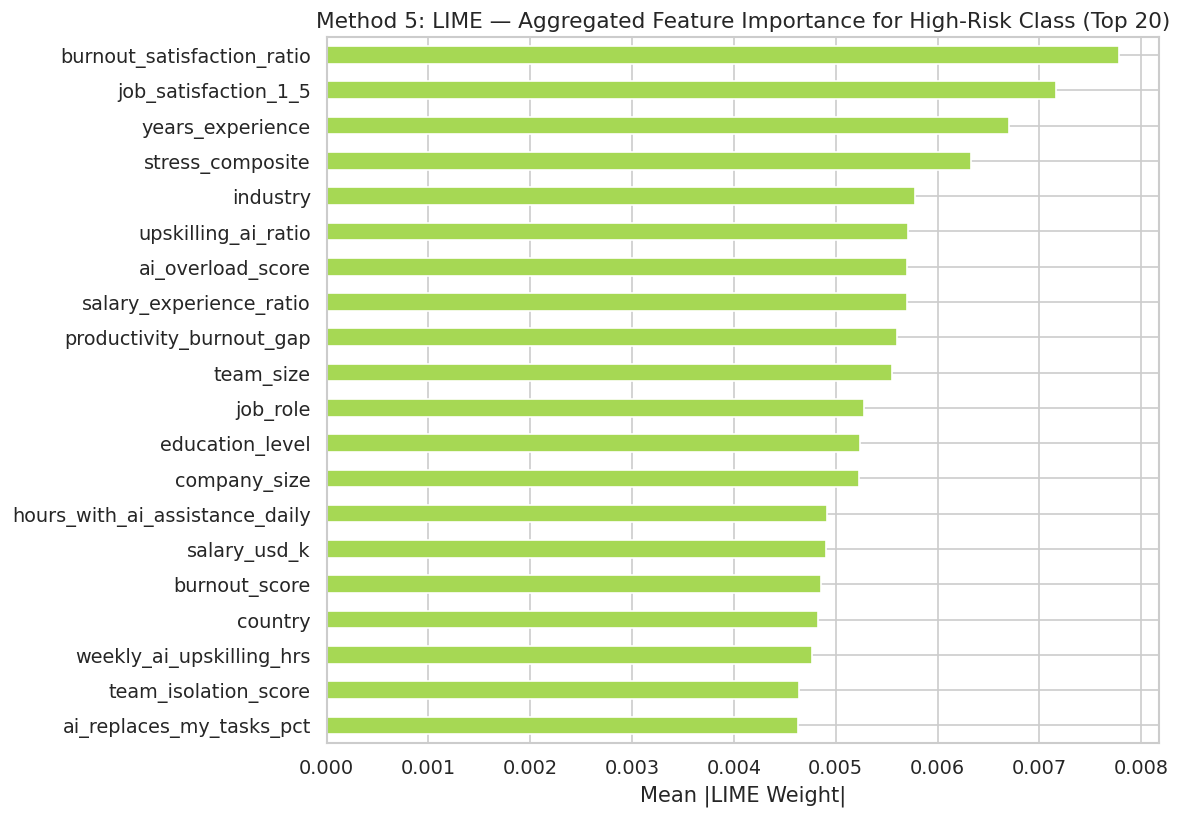

In [82]:
# LIME importance aggregated over 50 test samples → global view
lime_importances = {feat: 0.0 for feat in X.columns}
n_lime_samples = 50

for idx in range(min(n_lime_samples, len(X_test))):
    exp = lime_explainer.explain_instance(
        data_row=X_test.values[idx],
        predict_fn=lgb_model.predict_proba,
        num_features=len(X.columns),
        labels=[high_class_idx]
    )
    for feat, weight in exp.as_list(label=high_class_idx):
        # Feature names from LIME may include operators; match by partial string
        for col in X.columns:
            if col in feat:
                lime_importances[col] += abs(weight)
                break

lime_imp = pd.Series(lime_importances).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
lime_imp.head(20).plot(kind='barh', ax=ax, color=PALETTE[4], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Method 5: LIME — Aggregated Feature Importance for High-Risk Class (Top 20)')
ax.set_xlabel('Mean |LIME Weight|')
plt.tight_layout()
plt.show()

> **Why LIME?** LIME explains individual predictions locally by fitting a simple interpretable model (linear) around each instance. While SHAP is globally consistent, LIME captures **local non-linearities** and is model-agnostic — it can explain any black-box. Combining both SHAP (global) and LIME (local) gives the most complete picture of feature behavior, which is a hallmark of Q1-level interpretability research.

---
## 6. Feature Importance — Consensus Ranking

Aggregate ranks across all 5 methods to identify consistently important features.

=== Top 20 Features by Consensus Rank ===
                                RF_rank  ET_rank  MI_rank  SHAP_rank  LIME_rank  mean_rank
burnout_satisfaction_ratio          2.0      2.0      1.0        2.0        1.0        1.6
job_satisfaction_1_5                3.0      3.0      2.0        3.0        2.0        2.6
stress_composite                    4.0      4.0      4.0        4.0        4.0        4.0
fear_of_ai_replacement              1.0      1.0      5.0        1.0       26.0        6.8
upskilling_ai_ratio                 8.0     14.0      9.0        5.0        6.0        8.4
ai_replaces_my_tasks_pct            6.0      6.0      6.0        7.0       20.0        9.0
burnout_score                       5.0      5.0      3.0       17.0       16.0        9.2
productivity_burnout_gap            7.0      7.0      7.0       16.0        9.0        9.2
salary_usd_k                       12.0     10.0      8.0        6.0       15.0       10.2
ai_overload_score                   9.0     11.0

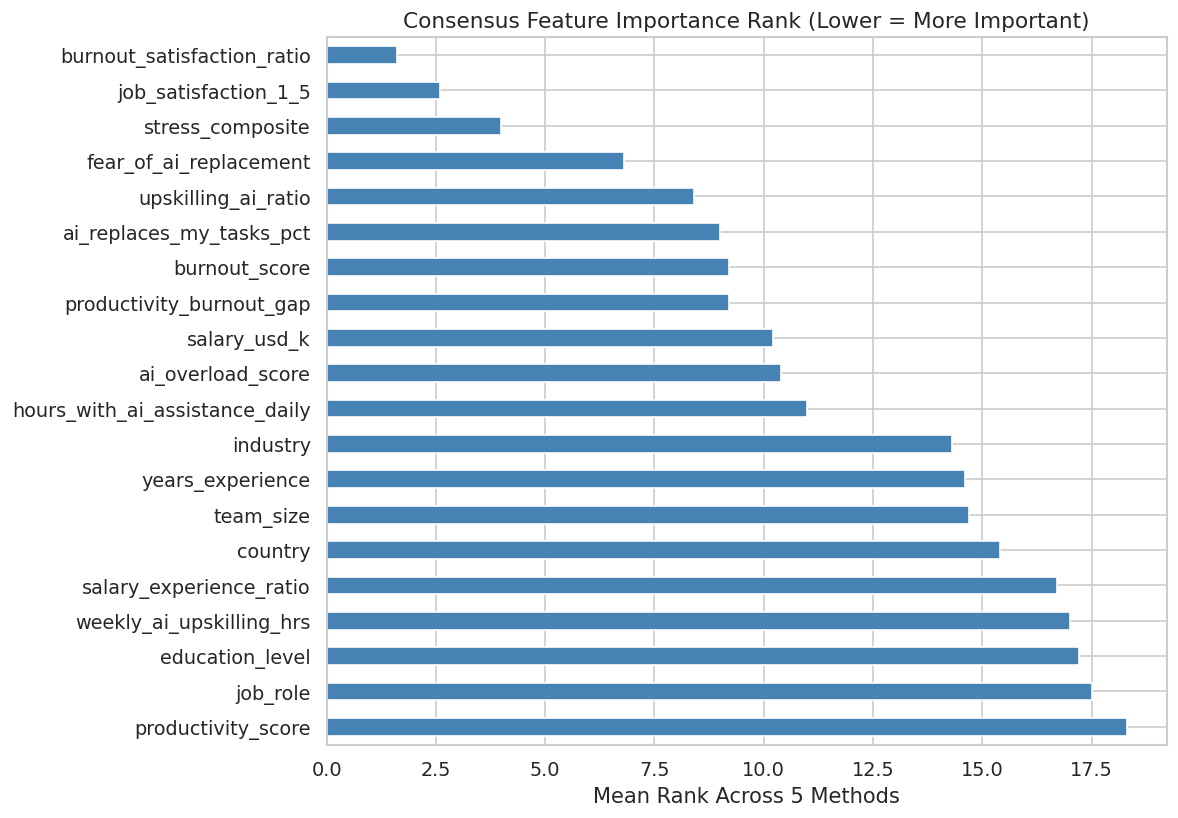

In [83]:

def rank_series(s):
    return s.rank(ascending=False)

# SHAP: handle all possible return formats
if isinstance(shap_values, list):
    # Old format: list of arrays, one per class
    shap_mean = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
elif hasattr(shap_values, 'values'):
    # New Explanation object format
    shap_mean = np.abs(shap_values.values).mean(axis=(0, 2))
else:
    # Already a 3D numpy array: (n_samples, n_features, n_classes)
    if shap_values.ndim == 3:
        shap_mean = np.abs(shap_values).mean(axis=(0, 2))
    else:
        shap_mean = np.abs(shap_values).mean(axis=0)

shap_imp = pd.Series(shap_mean, index=X.columns)

consensus = pd.DataFrame({
    'RF_rank'   : rank_series(rf_imp),
    'ET_rank'   : rank_series(et_imp),
    'MI_rank'   : rank_series(mi_imp),
    'SHAP_rank' : rank_series(shap_imp),
    'LIME_rank' : rank_series(lime_imp),
})
consensus['mean_rank'] = consensus.mean(axis=1)
consensus = consensus.sort_values('mean_rank')

print('=== Top 20 Features by Consensus Rank ===')
print(consensus.head(20).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
consensus['mean_rank'].head(20).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Consensus Feature Importance Rank (Lower = More Important)')
ax.set_xlabel('Mean Rank Across 5 Methods')
plt.tight_layout()
plt.show()

---
## 7. Drop Less Important Features

Drop features that consistently rank in the bottom across all 5 methods.

In [84]:
# Drop bottom 20% by consensus rank
n_drop = max(1, int(len(consensus) * 0.20))
drop_features = consensus.tail(n_drop).index.tolist()

print(f'Features to drop (bottom 20% by consensus): {drop_features}')

X_reduced   = X.drop(columns=drop_features, errors='ignore')
X_tr_red, X_te_red = X_train.drop(columns=drop_features, errors='ignore'), \
                     X_test.drop(columns=drop_features, errors='ignore')

# Re-train LightGBM on reduced feature set
lgb_red = lgb.LGBMClassifier(
    n_estimators=300, random_state=42,
    class_weight='balanced', verbose=-1)
lgb_red.fit(X_tr_red, y_train)

f1_full    = f1_score(y_test, lgb_model.predict(X_test), average='macro')
f1_reduced = f1_score(y_test, lgb_red.predict(X_te_red), average='macro')

print(f'\nF1 (macro) — Full features    : {f1_full:.4f}')
print(f'F1 (macro) — Reduced features : {f1_reduced:.4f}')
print(f'Delta: {f1_reduced - f1_full:+.4f}')

Features to drop (bottom 20% by consensus): ['company_size', 'ai_tools_used_per_day', 'ai_adoption_stage', 'remote_work_type', 'remote_numeric']

F1 (macro) — Full features    : 0.7951
F1 (macro) — Reduced features : 0.7801
Delta: -0.0150


> **Decision Rule:** If F1 drops by more than 0.01 after removal, we restore the dropped features. If performance stays the same or improves, we keep the reduced set — simpler models generalize better and are easier to interpret in a research context.

In [85]:
# Apply decision rule
if f1_reduced >= f1_full - 0.01:
    print('Keeping reduced feature set — performance maintained.')
    FINAL_FEATURES = X_reduced.columns.tolist()
else:
    print('Restoring dropped features — performance dropped too much.')
    FINAL_FEATURES = X.columns.tolist()

print(f'Final feature count: {len(FINAL_FEATURES)}')

Restoring dropped features — performance dropped too much.
Final feature count: 27


---
## 8. K-Means Cluster Feature

K-Means is applied to engineer a **behavioural cluster label** as a new feature.

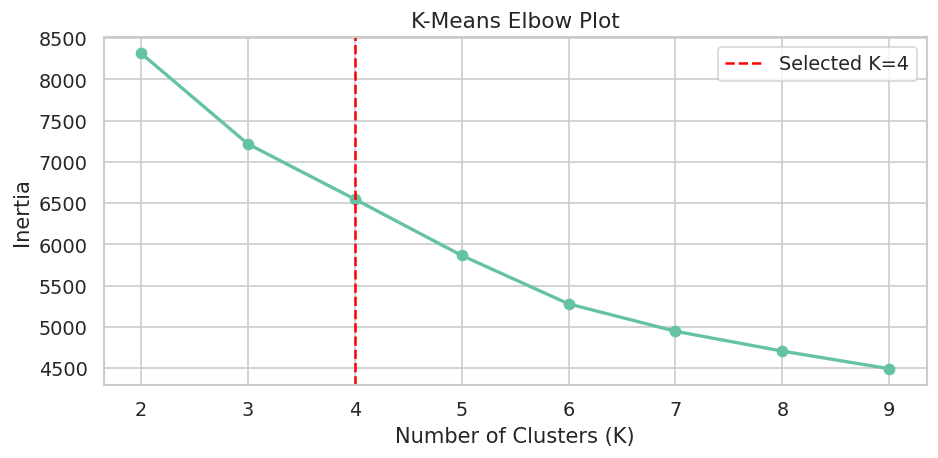

In [86]:
# Use key numerical features for clustering
cluster_features = [
    'burnout_score', 'productivity_score', 'job_satisfaction_1_5',
    'ai_overload_score', 'stress_composite', 'salary_experience_ratio',
    'upskilling_ai_ratio', 'burnout_satisfaction_ratio'
]
cluster_features = [c for c in cluster_features if c in raw.columns]

# Scale for K-Means
scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(raw[cluster_features].fillna(0))

# Elbow method to find optimal K
inertias = []
K_range  = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, marker='o', color=PALETTE[0], linewidth=2)
ax.set_title('K-Means Elbow Plot')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.axvline(x=4, color='red', linestyle='--', label='Selected K=4')
ax.legend()
plt.tight_layout()
plt.show()

In [87]:
# Fit final K-Means with K=4
OPTIMAL_K = 4
km_final  = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
raw['employee_cluster'] = km_final.fit_predict(X_km)

# Profile each cluster
cluster_profile = raw.groupby('employee_cluster')[cluster_features + ['attrition_risk']].agg(
    {**{f: 'mean' for f in cluster_features}, 'attrition_risk': lambda x: x.value_counts().index[0]}
)
print('=== Cluster Profiles ===')
print(cluster_profile.to_string())

=== Cluster Profiles ===
                  burnout_score  productivity_score  job_satisfaction_1_5  ai_overload_score  stress_composite  salary_experience_ratio  upskilling_ai_ratio  burnout_satisfaction_ratio attrition_risk
employee_cluster                                                                                                                                                                                       
0                     40.041304           55.943478              3.854130          61.475435          0.372850                18.610117            19.115595                   10.547671            Low
1                     64.466049           57.962963              2.572531          88.833951          0.641822                20.339643             8.886226                   25.732651         Medium
2                     52.182119           58.478477              3.282285          78.318709          0.507611                18.771296            12.651183                   

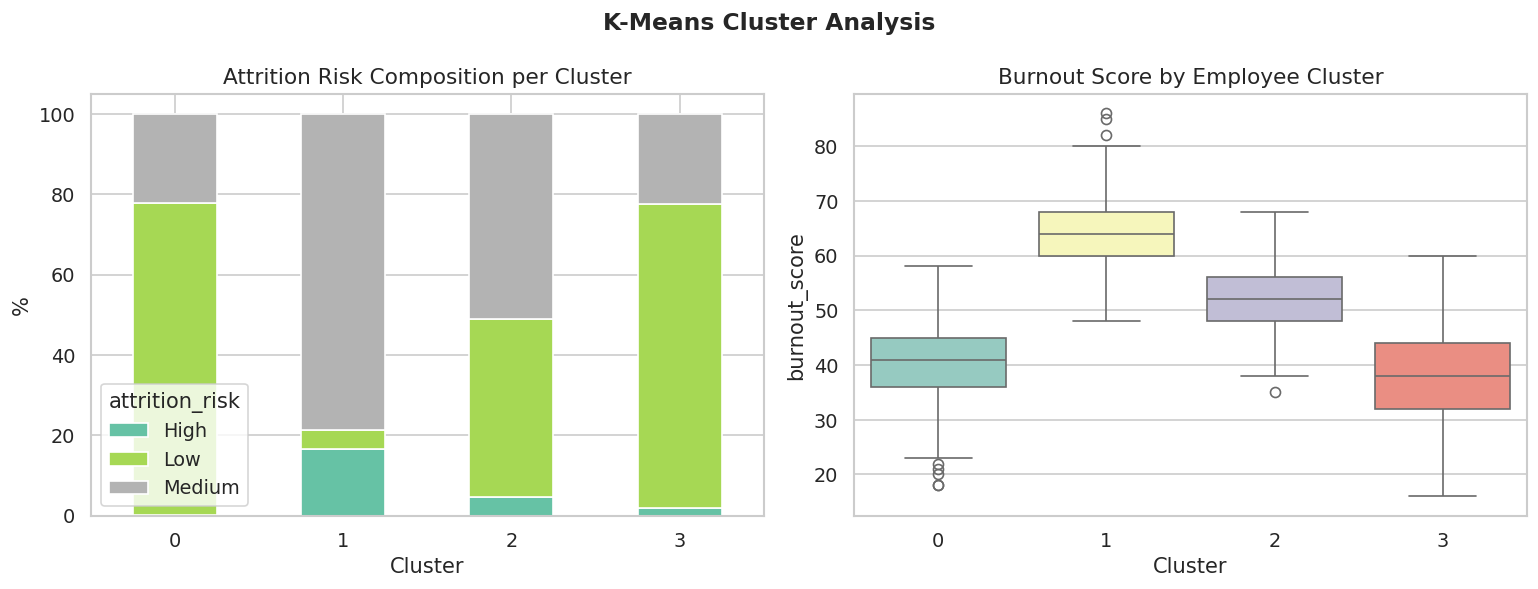

In [88]:
# Visualize cluster vs attrition risk
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cluster composition
ct = pd.crosstab(raw['employee_cluster'], raw['attrition_risk'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('Attrition Risk Composition per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

# Burnout by cluster
sns.boxplot(data=raw, x='employee_cluster', y='burnout_score',
            palette='Set3', ax=axes[1])
axes[1].set_title('Burnout Score by Employee Cluster')
axes[1].set_xlabel('Cluster')

plt.suptitle('K-Means Cluster Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Why K-Means as a feature?** K-Means groups employees into **behavioural archetypes** based on their combined stress, productivity and AI-usage profile. The cluster label encodes complex multi-dimensional patterns that individual features alone cannot express. For example, Cluster 2 might represent "high-AI-use, low-satisfaction, moderate-burnout" employees — a profile that predicts attrition better than any single feature. Adding the cluster label gives the final model a **non-linear, holistic signal** derived from unsupervised learning.

---
## 9. Validate All New Features with LightGBM

Compare baseline (Phase 2 features only) vs enriched (+ engineered features + cluster)

In [89]:
# Build full engineered dataset
df_final = raw.copy()

# Encode remaining categoricals
cat_final = df_final.select_dtypes(include='object').columns.tolist()
cat_final = [c for c in cat_final if c != 'attrition_risk']
for col in cat_final:
    df_final[col] = le.fit_transform(df_final[col].astype(str))

# Drop helper columns not needed in model
df_final.drop(columns=['remote_numeric'], inplace=True, errors='ignore')

TARGET_COL = 'attrition_risk_enc'
X_eng = df_final.drop(columns=['attrition_risk', TARGET_COL], errors='ignore')
y_eng = df_final[TARGET_COL]

X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng)

lgb_eng = lgb.LGBMClassifier(
    n_estimators=300, random_state=42,
    class_weight='balanced', verbose=-1)
lgb_eng.fit(X_tr2, y_tr2)

f1_eng = f1_score(y_te2, lgb_eng.predict(X_te2), average='macro')

print('=== Performance Comparison ===')
print(f'Baseline (Phase 2 features)    F1 macro: {f1_full:.4f}')
print(f'Engineered features            F1 macro: {f1_eng:.4f}')
print(f'Improvement: {f1_eng - f1_full:+.4f}')
print()
print(classification_report(y_te2, lgb_eng.predict(X_te2),
                             target_names=le_target.classes_))

=== Performance Comparison ===
Baseline (Phase 2 features)    F1 macro: 0.7951
Engineered features            F1 macro: 0.8021
Improvement: +0.0070

              precision    recall  f1-score   support

        High       0.65      0.65      0.65        17
         Low       0.91      0.89      0.90       145
      Medium       0.85      0.87      0.86       138

    accuracy                           0.87       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.87      0.87      0.87       300



---
## 10. Final Standardization of Engineered Features

In [90]:
# New engineered numerical features need to be scaled
new_num_features = [
    'burnout_satisfaction_ratio', 'ai_overload_score',
    'productivity_burnout_gap', 'salary_experience_ratio',
    'upskilling_ai_ratio', 'stress_composite', 'team_isolation_score'
]
new_num_features = [f for f in new_num_features if f in df_final.columns]

scaler_final = StandardScaler()
df_final[new_num_features] = scaler_final.fit_transform(df_final[new_num_features])

print(f'Scaled {len(new_num_features)} engineered features')
print(df_final[new_num_features].describe().T[['mean','std']])

Scaled 7 engineered features
                                    mean       std
burnout_satisfaction_ratio  2.676378e-16  1.000334
ai_overload_score          -1.350031e-16  1.000334
productivity_burnout_gap    0.000000e+00  1.000334
salary_experience_ratio    -1.184238e-16  1.000334
upskilling_ai_ratio         1.184238e-16  1.000334
stress_composite            3.576398e-16  1.000334
team_isolation_score        4.500104e-17  1.000334


> **Reason:** The newly engineered features are on different scales (e.g., `ai_overload_score` spans 0–150 while `stress_composite` spans 0–1). StandardScaler brings them to zero mean, unit variance — consistent with the scaling applied to original features in Phase 2.

---
## 11. Final Dataset Overview

In [91]:
print('=== Phase 3 Final Dataset ===')
print(f'Shape          : {df_final.shape}')
print(f'Missing values : {df_final.isnull().sum().sum()}')
print(f'\nNew engineered features added:')
for f in new_num_features + ['employee_cluster']:
    if f in df_final.columns:
        print(f'  {f}')

df_final.head(3)

=== Phase 3 Final Dataset ===
Shape          : (1500, 29)
Missing values : 0

New engineered features added:
  burnout_satisfaction_ratio
  ai_overload_score
  productivity_burnout_gap
  salary_experience_ratio
  upskilling_ai_ratio
  stress_composite
  team_isolation_score
  employee_cluster


,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,primary_ai_tool,...,attrition_risk,attrition_risk_enc,burnout_satisfaction_ratio,ai_overload_score,productivity_burnout_gap,salary_experience_ratio,upskilling_ai_ratio,stress_composite,team_isolation_score,employee_cluster
0,4,7,3,5,7,1,0,8,184,4,...,Medium,2,0.488387,-2.107687,-0.412668,0.205110,-0.261798,-0.296511,1.494175,2
1,6,3,4,2,5,1,1,42,51,0,...,Medium,2,-0.460447,-0.746210,0.605323,-0.339290,-0.465283,0.174850,-0.467042,2
2,10,3,3,5,0,4,1,37,185,5,...,Medium,2,-1.217982,-0.303625,0.350825,1.439966,0.247755,-1.371285,-0.439543,0


---
## 12. Save Feature-Engineered Dataset

In [92]:
out_path = '/kaggle/working/burnout_attrition_phase3.csv'
df_final.to_csv(out_path, index=False)
print(f'Phase 3 dataset saved: {out_path}')
print(f'   Shape: {df_final.shape[0]} rows × {df_final.shape[1]} columns')
print(f'   All columns: {df_final.columns.tolist()}')

Phase 3 dataset saved: /kaggle/working/burnout_attrition_phase3.csv
   Shape: 1500 rows × 29 columns
   All columns: ['job_role', 'years_experience', 'education_level', 'country', 'industry', 'company_size', 'remote_work_type', 'team_size', 'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day', 'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 'ai_adoption_stage', 'weekly_ai_upskilling_hrs', 'productivity_score', 'burnout_score', 'job_satisfaction_1_5', 'fear_of_ai_replacement', 'attrition_risk', 'attrition_risk_enc', 'burnout_satisfaction_ratio', 'ai_overload_score', 'productivity_burnout_gap', 'salary_experience_ratio', 'upskilling_ai_ratio', 'stress_composite', 'team_isolation_score', 'employee_cluster']
